# Machine Learning con scikit-learn
## KNN y Naive Bayes — Credit Card Fraud Detection
**Fuente:** [Kaggle - mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

- **284,807 transacciones** de tarjetas de crédito europeas (septiembre 2013)
- **30 features** numéricas (V1–V28 via PCA, Time, Amount)
- **Target `Class`**: 0 = legítima, 1 = fraude


In [ ]:
# ==============================================================
# CELDA 1: Cargar el dataset
# ==============================================================
from google.colab import files
uploaded = files.upload()  # Seselecciona el dataset creditcard.csv

Saving creditcard.csv to creditcard.csv


In [ ]:
# ==============================================================
# CELDA 2: Imports y exploración inicial
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Cargar el dataset
df = pd.read_csv('creditcard.csv')
print("Shape del dataset:", df.shape)
print("\nDistribución de clases:")
print(df['Class'].value_counts())
print(f"\n% Fraudes: {df['Class'].mean()*100:.4f}%")
df.head()

Shape del dataset: (284807, 31)

Distribución de clases:
Class
0    284315
1       492
Name: count, dtype: int64

% Fraudes: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# ==============================================================
# CELDA 3: Preparación de datos
# Usamos V1 y V2 para mantener la misma estructura que en
# Regresión Logística (2 features ; visualización de fronteras)
# ==============================================================

# Features y etiquetas
iris_x = df[['V1', 'V2']].values      # Características. Seleccionamos 2
iris_y = df['Class'].values           # Etiquetas: 0=legítima, 1=fraude

# Imprimir formas
print(iris_x.shape, iris_y.shape)

# Escalar features
scaler = StandardScaler()
iris_x = scaler.fit_transform(iris_x)

# Split en train/test para evaluación correcta
X_train, X_test, y_train, y_test = train_test_split(
    iris_x, iris_y, test_size=0.2, random_state=42, stratify=iris_y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Fraudes en train: {y_train.sum()} | Fraudes en test: {y_test.sum()}")

(284807, 2) (284807,)

Train: (227845, 2) | Test: (56962, 2)
Fraudes en train: 394 | Fraudes en test: 98


---
# PARTE 1: K-Nearest Neighbors (KNN)

**Documentación:** https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

**Idea:** Clasifica una muestra nueva según las `k` muestras más cercanas en el espacio de features.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier  # KNN: scikit-learn

# Instancia del clasificador KNN (k=5 por defecto)
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenar el modelo KNN
knn.fit(X_train, y_train)  # (#muestras, #caracteristicas)

# Predecir el conjunto de test
knn_y_pred = knn.predict(X_test)

# Imprimir los valores estimados para compararlos respecto a los originales
print("--- KNN (k=5) - Métricas de Evaluación ---")
print(classification_report(y_test, knn_y_pred, target_names=['Legítima', 'Fraude']))

--- KNN (k=5) - Métricas de Evaluación ---
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.69      0.20      0.31        98

    accuracy                           1.00     56962
   macro avg       0.84      0.60      0.66     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Nueva muestra. Imprime el valor correspondiente y la prediccion
new_sample = np.array([[2.0, -1.5]])  # Una transacción de ejemplo (V1=2.0, V2=-1.5)
new_sample_scaled = scaler.transform(new_sample)

prediction = knn.predict(new_sample_scaled)
prob = knn.predict_proba(new_sample_scaled)

print(f"Nueva muestra: V1={new_sample[0,0]}, V2={new_sample[0,1]}")
print(f"Predicción KNN: {'🚨 FRAUDE' if prediction[0]==1 else '✅ Legítima'}")
print(f"Probabilidad [Legítima, Fraude]: {prob[0]}")

Nueva muestra: V1=2.0, V2=-1.5
Predicción KNN: ✅ Legítima
Probabilidad [Legítima, Fraude]: [1. 0.]


## Fronteras de decisión — KNN

(168993,)


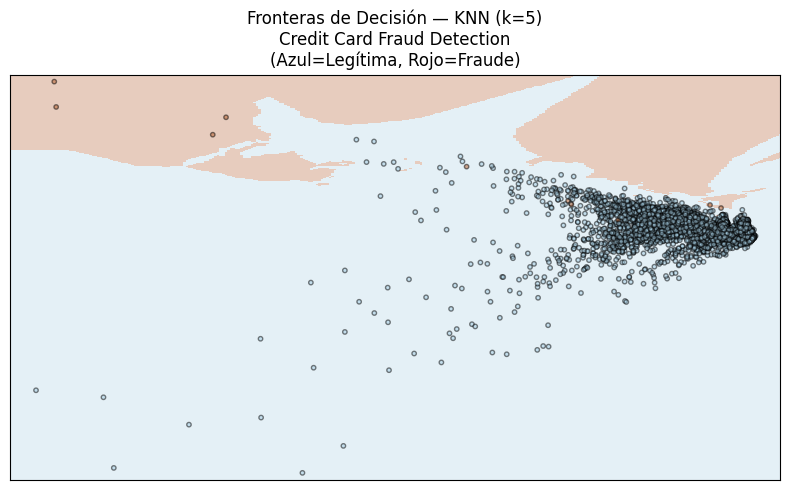

In [ ]:
# Submuestra para visualización eficiente
sample_idx = np.random.choice(len(iris_x), size=8000, replace=False)
x = iris_x[sample_idx]
y_sample = iris_y[sample_idx]

# Valores minimos y maximos para crear el grid de las fronteras de decision
x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

# Crear el grid de las fronteras de decision
x_grid, y_grid = np.meshgrid(np.arange(x_min, x_max, 0.05),
                               np.arange(y_min, y_max, 0.05))

# Predecir los valores del grid
predictions = knn.predict(np.c_[x_grid.ravel(), y_grid.ravel()])
print(predictions.shape)

# Encajar las predicciones al tamaño del grid
predictions = predictions.reshape(x_grid.shape)

# Dibujar el grid y las fronteras de decision
_, ax = plt.subplots(figsize=(8, 5))
ax.pcolormesh(x_grid, y_grid, predictions, cmap=plt.cm.Paired, alpha=0.3)

# Imprimir las muestras con el scatter
ax.scatter(x[:, 0], x[:, 1], c=y_sample, edgecolors='k', cmap=plt.cm.Paired,
           s=10, alpha=0.5)

ax.set_xlim(x_grid.min(), x_grid.max())
ax.set_ylim(y_grid.min(), y_grid.max())
ax.set_xticks(())
ax.set_yticks(())
ax.set_title('Fronteras de Decisión — KNN (k=5)\nCredit Card Fraud Detection\n(Azul=Legítima, Rojo=Fraude)')
plt.tight_layout()
plt.show()

## Eligiendo el mejor K

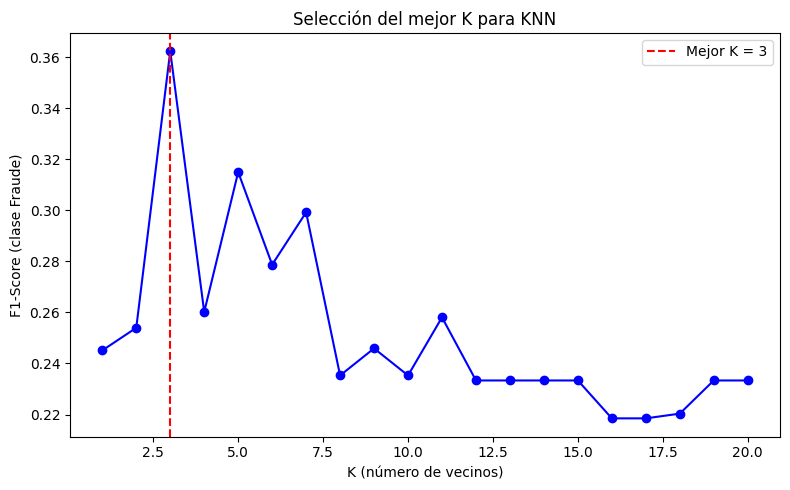

Mejor K: 3 | F1-Score: 0.3623


In [ ]:
from sklearn.metrics import f1_score

# Probar diferentes valores de K
k_values = range(1, 21)
f1_scores = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    pred_k = knn_k.predict(X_test)
    f1_scores.append(f1_score(y_test, pred_k, pos_label=1))

_, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, f1_scores, marker='o', color='blue')
ax.axvline(x=k_values[np.argmax(f1_scores)], color='red', linestyle='--',
           label=f'Mejor K = {k_values[np.argmax(f1_scores)]}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('F1-Score (clase Fraude)')
ax.set_title('Selección del mejor K para KNN')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mejor K: {k_values[np.argmax(f1_scores)]} | F1-Score: {max(f1_scores):.4f}")

---
# PARTE 2: Naive Bayes

**Documentación:** https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html

**Idea:** Usa el Teorema de Bayes asumiendo independencia entre features. `GaussianNB` asume que las features siguen una distribución normal.

In [ ]:
from sklearn.naive_bayes import GaussianNB  # Naive Bayes: scikit-learn

# Instancia del clasificador Naive Bayes
naive_bayes = GaussianNB()

# Entrenar el modelo Naive Bayes
naive_bayes.fit(X_train, y_train)  # (#muestras, #caracteristicas)

# Predecir el conjunto de test
nb_y_pred = naive_bayes.predict(X_test)

# Imprimir los valores estimados para compararlos respecto a los originales
print("--- Naive Bayes (GaussianNB) - Métricas de Evaluación ---")
print(classification_report(y_test, nb_y_pred, target_names=['Legítima', 'Fraude']))

--- Naive Bayes (GaussianNB) - Métricas de Evaluación ---
              precision    recall  f1-score   support

    Legítima       1.00      0.99      0.99     56864
      Fraude       0.03      0.28      0.06        98

    accuracy                           0.99     56962
   macro avg       0.52      0.63      0.53     56962
weighted avg       1.00      0.99      0.99     56962



In [ ]:
# Nueva muestra. Imprime el valor correspondiente y la prediccion
new_sample = np.array([[2.0, -1.5]])
new_sample_scaled = scaler.transform(new_sample)

prediction_nb = naive_bayes.predict(new_sample_scaled)
prob_nb = naive_bayes.predict_proba(new_sample_scaled)

print(f"Nueva muestra: V1={new_sample[0,0]}, V2={new_sample[0,1]}")
print(f"Predicción Naive Bayes: {'🚨 FRAUDE' if prediction_nb[0]==1 else '✅ Legítima'}")
print(f"Probabilidad [Legítima, Fraude]: {prob_nb[0]}")

Nueva muestra: V1=2.0, V2=-1.5
Predicción Naive Bayes: ✅ Legítima
Probabilidad [Legítima, Fraude]: [9.99852593e-01 1.47407293e-04]


## Fronteras de decisión — Naive Bayes

(168993,)


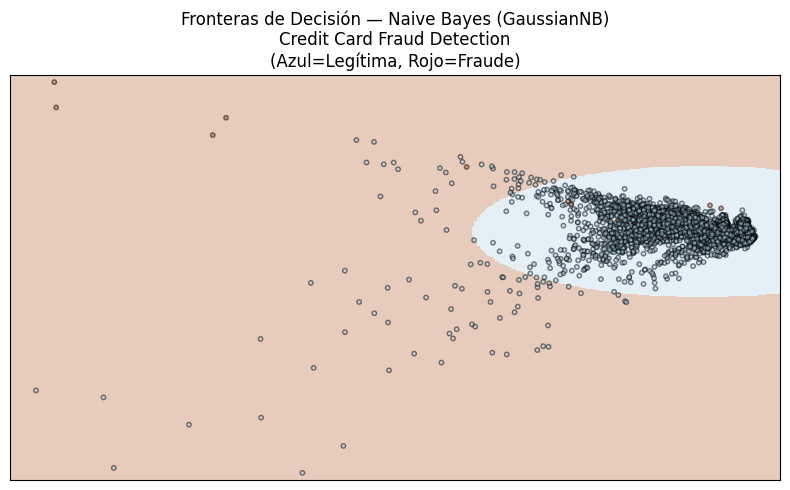

In [ ]:
# Reutilizamos el mismo grid del KNN
predictions_nb = naive_bayes.predict(np.c_[x_grid.ravel(), y_grid.ravel()])
print(predictions_nb.shape)
predictions_nb = predictions_nb.reshape(x_grid.shape)

# Dibujar el grid y las fronteras de decision
_, ax = plt.subplots(figsize=(8, 5))
ax.pcolormesh(x_grid, y_grid, predictions_nb, cmap=plt.cm.Paired, alpha=0.3)

# Imprimir las muestras con el scatter
ax.scatter(x[:, 0], x[:, 1], c=y_sample, edgecolors='k', cmap=plt.cm.Paired,
           s=10, alpha=0.5)

ax.set_xlim(x_grid.min(), x_grid.max())
ax.set_ylim(y_grid.min(), y_grid.max())
ax.set_xticks(())
ax.set_yticks(())
ax.set_title('Fronteras de Decisión — Naive Bayes (GaussianNB)\nCredit Card Fraud Detection\n(Azul=Legítima, Rojo=Fraude)')
plt.tight_layout()
plt.show()

---
# PARTE 3: Comparación de los 4 modelos
Regresión Logística vs KNN vs Naive Bayes

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

# Reentrenar regresión logística con el mismo split para comparar
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_test)

# Mejores KNN con el K óptimo encontrado
best_k = k_values[np.argmax(f1_scores)]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
knn_pred = knn_best.predict(X_test)

modelos = {
    'Regresión Logística': log_pred,
    f'KNN (k={best_k})':   knn_pred,
    'Naive Bayes':         nb_y_pred
}

print(f"{'Modelo':<25} {'F1 (Fraude)':>12} {'AUC-ROC':>10}")
print("-" * 50)
for nombre, pred in modelos.items():
    f1 = f1_score(y_test, pred, pos_label=1)
    auc = roc_auc_score(y_test, pred)
    print(f"{nombre:<25} {f1:>12.4f} {auc:>10.4f}")

Modelo                     F1 (Fraude)    AUC-ROC
--------------------------------------------------
Regresión Logística             0.1930     0.5561
KNN (k=3)                       0.3623     0.6274
Naive Bayes                     0.0619     0.6312


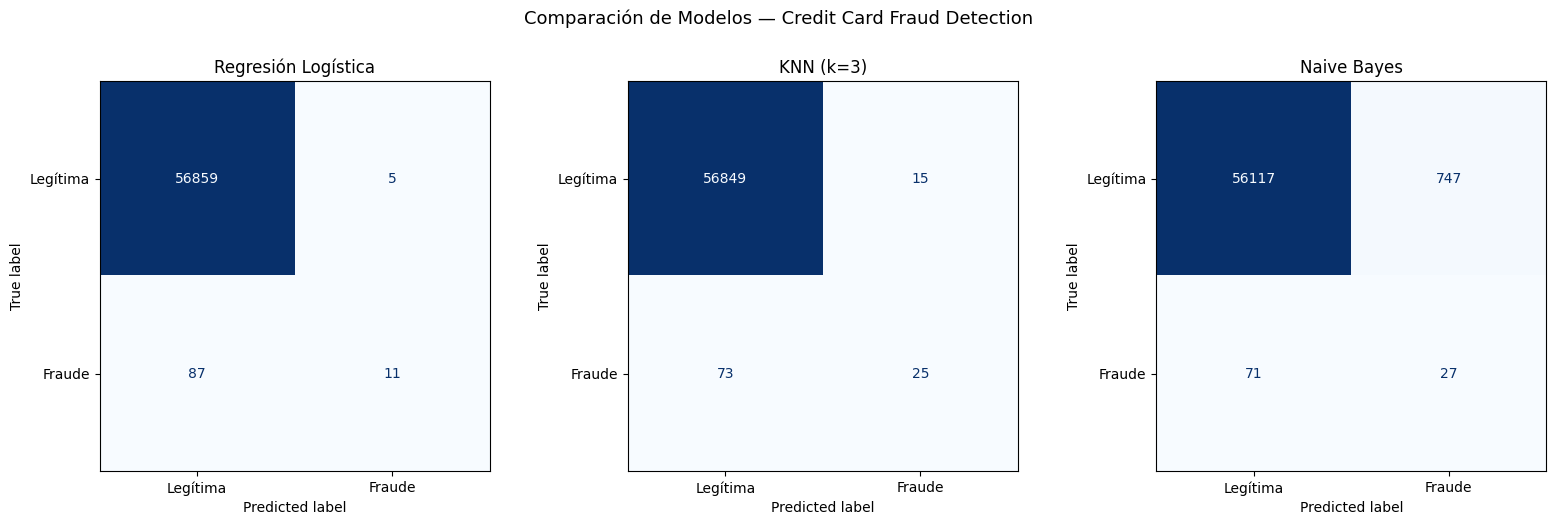

In [ ]:
# Comparación visual con matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, pred) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítima', 'Fraude'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre)

plt.suptitle('Comparación de Modelos — Credit Card Fraud Detection', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

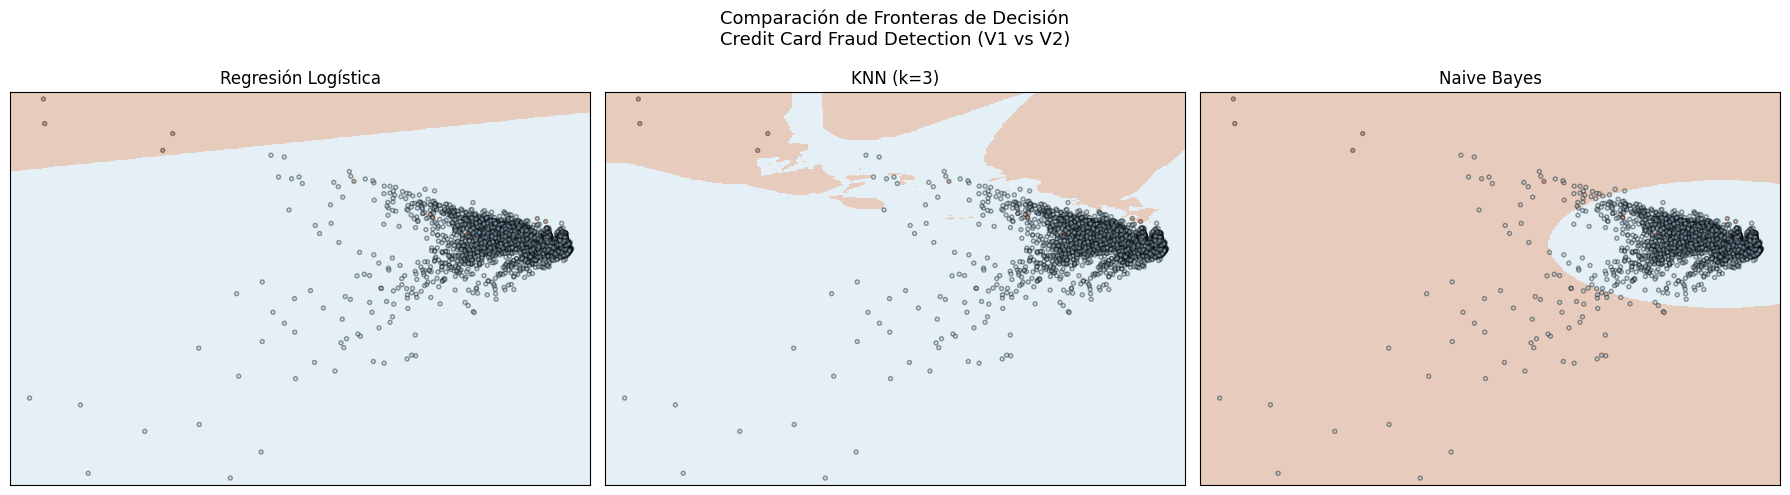

In [ ]:
# Comparación de fronteras de decisión lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titulos = ['Regresión Logística', f'KNN (k={best_k})', 'Naive Bayes']
clasificadores = [log_reg, knn_best, naive_bayes]

for ax, titulo, clf in zip(axes, titulos, clasificadores):
    pred_grid = clf.predict(np.c_[x_grid.ravel(), y_grid.ravel()])
    pred_grid = pred_grid.reshape(x_grid.shape)
    ax.pcolormesh(x_grid, y_grid, pred_grid, cmap=plt.cm.Paired, alpha=0.3)
    ax.scatter(x[:, 0], x[:, 1], c=y_sample, edgecolors='k',
               cmap=plt.cm.Paired, s=8, alpha=0.4)
    ax.set_xlim(x_grid.min(), x_grid.max())
    ax.set_ylim(y_grid.min(), y_grid.max())
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(titulo)

plt.suptitle('Comparación de Fronteras de Decisión\nCredit Card Fraud Detection (V1 vs V2)', fontsize=13)
plt.tight_layout()
plt.show()